# Setup

In [2]:
import pandas as pd

In [3]:
search_df = pd.read_parquet("data/raw_data/search_dataset.parquet")

In [4]:
"""
Voice-to-text, though process archive.

Questions coming to mind observing and analyzing the search dataset as I go through it. I'm looking at date time and timestamp. There are particular user IDs we're looking at the app country the keyword used for search just to just reflect on this search can happen or can vary naturally across periods of time. There might be some user IDs that skew search more than others depending on how often they search. We can also look at the app country column which can help us understand which regions search for what on average and then we can look at keywords. These are just some initial thoughts.

Continuing to look at the dataset, we have the product ID which might have been returned given the search keyword. Did that happen in that particular session? I need to figure out if I can break things down by sessions. Maybe there is no session ID so I can create session IDs based on timestamps and date times if that's not already there. So product IDs are viewed product classes So opportunity to kind of analyze which product classes are viewed and after product class you have this specific class I guess so it could be a subcategory in which case we need to handle naming it better. Then we have designer so we can look at which designer influences results or is more dominant in results. We have name of the product. Then we have plp view click is converted. So this is like the behavioral data that we have, right? The PLP view is the impression of they've seen the product given its placement probably clicking is if it got clicked on so meaning this could be gauge for a hit is converted as even a stronger signal so this is what we're dealing with.

Now I need to reflect on the case study to kind of understand what matters here before I delve into any deep research

The first question being asked is how to measure search performance using this dataset. We are limited to the data that's given, so we need to determine when a keyword search is in fact returning a hit right so a keyword search is gonna return i'm guessing a number of different product IDs each should have corresponding metadata such as viewing, clicking, conversion. I think we need to define what success is to begin with, and the way I would do it here because we have conversion clicking and viewing as potential data points is I would follow a weighted format meaning impressions should get the lowest weight if that's the only success that exists clicking should add even more worth and conversion should be a very strong signal so what we're looking for here is maybe some kind of weighted success factoring in these results. 

The second question being asked is identifying or has to do with identifying which queries perform poorly and why and how would you define poor search performance. To answer this question, there needs to be some exploration. when it comes to the definition of poor search performance, however, we might be able to use the definition of success that we agreed on earlier if that's how we're going to move forward meaning a low score or no view, no click, no conversion is a failure potentially.
So the first step would be to define what a failure is and then searching the data so that we can identify samples that reflect poor performance and then we can delve deeper and analyze the distribution of those results across a number of different dimensions to figure out what's causing the issue. What this is gonna help with is Perhaps constructing a baseline search algorithm that is simple yet is adapted to handle the edge cases that are baked within the dataset distribution.

The third question being asked is how does position or the index event clicks and how do you correct for that bias? one assumption that we can make is or a hypothesis that we can state is items that are positioned at the very beginning of the recommendation might bias results. And that can be tested through a hypothesis test, maybe a t-test, looking at the average clicks across items that are positioned at the beginning or first half versus the second half of the index. And if that's the case, if we can validate that hypothesis, that bias, then one way to potentially work around it is through either randomization or ranking.

On the point of data understanding is can we segment queries into different intent types? This requires us to cluster queries to understand the degree to which they vary and whether there are patterns that can be described as intent. In which case if we can do that then we can zone in on those distributions and try to understand them. To see if they indeed behave differently. And this will inform further strategy.

"""

"\nVoice-to-text, though process archive.\n\nQuestions coming to mind observing and analyzing the search dataset as I go through it. I'm looking at date time and timestamp. There are particular user IDs we're looking at the app country the keyword used for search just to just reflect on this search can happen or can vary naturally across periods of time. There might be some user IDs that skew search more than others depending on how often they search. We can also look at the app country column which can help us understand which regions search for what on average and then we can look at keywords. These are just some initial thoughts.\n\nContinuing to look at the dataset, we have the product ID which might have been returned given the search keyword. Did that happen in that particular session? I need to figure out if I can break things down by sessions. Maybe there is no session ID so I can create session IDs based on timestamps and date times if that's not already there. So product IDs 

In [5]:
search_df.head(1)

,dt,ts,user_id,app_country,keyword,index,product_id,productclass,class,designer,name,plp_view,plp_click,is_converted
0,2025-08-01,2025-08-01 23:46:54,68AE15DFBB9B525A0DD274B3624C7B6B468EFCA177EC87...,Country_A,Cap,16,1FFEB66ED2A6AB3CB88D019FC8282CC005D4BC16ED113D...,Accessories,Hats,Zegna,Baseball Cap in Technical Fabric,1,0,0


# EDA

## Language detection and catalog analysis

In [ ]:
import regex as re

def detect_script(text):
    if pd.isna(text):
        return 'unknown'
    
    text = str(text)
    has_arabic = bool(re.search(r'\p{Arabic}', text))
    has_latin = bool(re.search(r'\p{Latin}', text))
    
    if has_arabic and has_latin:
        return 'mixed'
    elif has_arabic:
        return 'arabic'
    elif has_latin:
        return 'latin'
    else:
        return 'other'

search_df['keyword_type'] = search_df['keyword'].apply(detect_script)


In [ ]:
script_dist = search_df['keyword_type'].value_counts(normalize=True) * 100
print(script_dist)


In [ ]:
keyword_type_analysis = search_df.groupby('keyword_type').agg({
    'plp_click': ['count', 'sum', 'mean'],  
    'is_converted': 'mean'  #
})
print(keyword_type_analysis)

In [ ]:
designer_dist = search_df['designer'].value_counts(normalize=True) * 100
print(designer_dist)


In [ ]:
search_df["designer_lang_detected"] = search_df['designer'].apply(detect_script)


In [106]:
keyword_search_columns = ["productclass","class","designer","name","product_id"]# assumption

In [107]:
catalog_df = search_df[keyword_search_columns]

In [114]:
catalog_df

,productclass,class,designer,name,product_id
3731325,Shoes,Flats,Tory Burch,Ines Sport Slides in Leather,FE1405E3F18D326A96295B4EDCB549F70B635C25770861...
2915275,Shoes,Flats,Tory Burch,Ines Sport Slides in Suede,A747F9D5C97DC631268314DA0918FB2E80480D458F7402...
2122481,Shoes,Flats,Tory Burch,T Sport Slide Sandals in Leather,FCF295C9E126DD98AA0390D8069EB0FE21CA9A57CD7A5E...
3140364,Shoes,Flats,Schutz,Enola Sporty Sandals in Woven Leather,B8F84D142342FF6291631B2F4E835066AE1B86A83EA7DB...
3065608,Shoes,Flats,Tory Burch,Ines Sport Slides in Leather,1DAF3184C9446B983207A923CDE96922F722377652ACDE...
...,...,...,...,...,...
4023713,Shoes,Heels,Balenciaga,BB 80 Knife Sandals in Satin,3ECB62029D6EF5887A242A143D7CE12933C7DAADB2FE42...
3004899,NaN,NaN,NaN,NaN,89336C4B1B4EDBC27EB3BCF5543C96AFAFC148AB490B09...
3116753,Shoes,Heels,Malone Souliers,Maureen 100 Mules in Nappa & Patent Leather,77167288B139865121F586C120A125DC5A57F8819C9CA0...
2377222,Shoes,Heels,Chloé,Maxime 130 Wedge Sandals in Leather,F0A55A6952D085D626E3DAACAC8B4C874E069EE8193BD2...


In [116]:
catalog_df = catalog_df.drop_duplicates("product_id").sort_values("designer")

In [123]:
round(float(catalog_df.designer.isna().sum() / len(catalog_df) * 100),3)

4.142

In [124]:
round(float(catalog_df.name.isna().sum() / len(catalog_df) * 100),3)

4.138

In [125]:
search_df[["name", "designer", "class", "productclass"]].isnull().mean()


name            0.049483
designer        0.049490
class           0.049483
productclass    0.049490
dtype: float64

In [126]:
search_df.groupby(search_df["designer"].isnull()).agg(
    impressions=("plp_click", "count"),
    ctr=("plp_click", "mean"),
    conversion=("is_converted", "mean")
)

,impressions,ctr,conversion
designer,,,
False,3910293,0.020124,0.00128
True,203598,0.019150,0.00000


## Q1 and Q2

In [6]:
# Let's look at user_id and keyword grouping
search_df.groupby(["user_id","keyword"]).agg(
    Total_Count=('index', 'count')
).reset_index()

,user_id,keyword,Total_Count
0,00006617A3D6DBEC8649E27874B5307170CF25B5A7E0A8...,حذاء رياضيه,8
1,00074F934804C0F4AAFE1B7BA7AF7EB6F26A5D460254E4...,and wander,76
2,00074F934804C0F4AAFE1B7BA7AF7EB6F26A5D460254E4...,backpack,104
3,00074F934804C0F4AAFE1B7BA7AF7EB6F26A5D460254E4...,gramicci bag,3
4,00074F934804C0F4AAFE1B7BA7AF7EB6F26A5D460254E4...,hiking,97
...,...,...,...
45940,FFF9115FC1ECC3339BC497F9328DDFE2EFC96452666E7D...,Poli,4
45941,FFF9115FC1ECC3339BC497F9328DDFE2EFC96452666E7D...,Polo,16
45942,FFF9115FC1ECC3339BC497F9328DDFE2EFC96452666E7D...,Ralph,8
45943,FFF9115FC1ECC3339BC497F9328DDFE2EFC96452666E7D...,Ralph lauren,8


In [7]:
# quick check for uniqueness
conditionx = search_df.user_id == "00074F934804C0F4AAFE1B7BA7AF7EB6F26A5D460254E408492683A678C3D219"
conditiony = search_df.keyword == "and wander"
search_df[(conditionx) & (conditiony)].index.nunique() == len(search_df[(conditionx) & (conditiony)])



True

In [8]:
# run global check to validate finding
search_df.groupby(["user_id", "keyword", "index"]).size().max()
# turns out duplicates exist - user_id x keyword aren't granular enough, might need to use a timestamp huerisitc for cutoff


np.int64(44)

In [9]:
# checking how drastic the duplication is
dupes = search_df.groupby(["user_id", "keyword", "index"]).size()

dupes[dupes > 1].describe()




count    543224.000000
mean          2.458518
std           1.057818
min           2.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          44.000000
dtype: float64

In [10]:
# breaking down query units through timestamps then checking for uniqueness on average

search_df = search_df.sort_values(["user_id", "keyword", "ts"])


In [11]:
search_df.head(2)

,dt,ts,user_id,app_country,keyword,index,product_id,productclass,class,designer,name,plp_view,plp_click,is_converted
2122481,2025-08-01,2025-08-01 10:20:49,00006617A3D6DBEC8649E27874B5307170CF25B5A7E0A8...,Country_B,حذاء رياضيه,3,FCF295C9E126DD98AA0390D8069EB0FE21CA9A57CD7A5E...,Shoes,Flats,Tory Burch,T Sport Slide Sandals in Leather,1,0,0
2444059,2025-08-01,2025-08-01 10:20:49,00006617A3D6DBEC8649E27874B5307170CF25B5A7E0A8...,Country_B,حذاء رياضيه,6,EB837CDB170BD825120D109468A228B58711BC56B3DB53...,Shoes,Flats,Schutz,Enola Sporty Sandals in Leather,1,0,0


In [12]:
search_df.ts.dtype

dtype('<M8[ns]')

In [13]:
query_signature_cols = ["user_id", "keyword","index","ts"]

In [14]:
qsig_df = search_df[query_signature_cols].sort_values(by=["user_id", "keyword","index"])

In [15]:
qsig_df

# After sorting, if user_id x keyword pair have correctly ordered index + ts_i < ts_j - merge

# lets try

,user_id,keyword,index,ts
3731325,00006617A3D6DBEC8649E27874B5307170CF25B5A7E0A8...,حذاء رياضيه,1,2025-08-01 10:20:49
2915275,00006617A3D6DBEC8649E27874B5307170CF25B5A7E0A8...,حذاء رياضيه,2,2025-08-01 10:20:49
2122481,00006617A3D6DBEC8649E27874B5307170CF25B5A7E0A8...,حذاء رياضيه,3,2025-08-01 10:20:49
3140364,00006617A3D6DBEC8649E27874B5307170CF25B5A7E0A8...,حذاء رياضيه,4,2025-08-01 10:20:49
3065608,00006617A3D6DBEC8649E27874B5307170CF25B5A7E0A8...,حذاء رياضيه,5,2025-08-01 10:20:49
...,...,...,...,...
4023713,FFFD0D21D1DF900E8B65F0FD574403C800EE152B4E042F...,Brown heels,13,2025-08-01 21:37:29
3004899,FFFD0D21D1DF900E8B65F0FD574403C800EE152B4E042F...,Brown heels,14,2025-08-01 21:37:29
3116753,FFFD0D21D1DF900E8B65F0FD574403C800EE152B4E042F...,Brown heels,15,2025-08-01 21:37:29
2377222,FFFD0D21D1DF900E8B65F0FD574403C800EE152B4E042F...,Brown heels,16,2025-08-01 21:37:29


In [16]:
search_df = search_df.sort_values(["user_id", "keyword", "ts", "index"])
search_df["index_reset"] = search_df.groupby(["user_id", "keyword"])["index"].diff() <= 0
search_df["index_reset"] = search_df["index_reset"].fillna(True)  # first row of each group starts a session
search_df["query_id"] = search_df.groupby(["user_id", "keyword"])["index_reset"].cumsum()


In [173]:
search_df.query_id.nunique()

4567

In [174]:
search_df.groupby(["user_id", "keyword", "query_id"]).ngroups


263602

In [19]:
search_df.groupby(["user_id", "keyword", "query_id", "index"]).size().max()


np.int64(1)

In [20]:
query_signature_final_cols = ["user_id", "keyword", "query_id"]

In [21]:
# More formally:
"""
within each user-keyword pair, monotonically increasing index values belong to the same search event, and any index that drops signals a new one. 
The query_id counter labels which search event each row belongs to.

"""

'\nwithin each user-keyword pair, monotonically increasing index values belong to the same search event, and any index that drops signals a new one. \nThe query_id counter labels which search event each row belongs to.\n\n'

In [36]:
query_metrics = search_df.groupby(query_signature_final_cols + ["keyword_type"]).agg(
    num_results=("product_id", "count"),
    num_clicks=("plp_click", "sum"),
    num_conversions=("is_converted", "sum"),
    first_click_position=("index", lambda x: x[search_df.loc[x.index, "plp_click"] == 1].min())
).reset_index()

In [37]:
query_metrics.head(3)

,user_id,keyword,query_id,keyword_type,num_results,num_clicks,num_conversions,first_click_position
0,00006617A3D6DBEC8649E27874B5307170CF25B5A7E0A8...,حذاء رياضيه,0.0,arabic,8,0,0,NaN
1,00074F934804C0F4AAFE1B7BA7AF7EB6F26A5D460254E4...,and wander,0.0,latin,4,0,0,NaN
2,00074F934804C0F4AAFE1B7BA7AF7EB6F26A5D460254E4...,and wander,1.0,latin,6,1,0,6.0


In [38]:
query_metrics["reciprocal_rank"] = (1 / query_metrics["first_click_position"]).fillna(0)
mrr = query_metrics["reciprocal_rank"].mean()

In [39]:
query_metrics.groupby("keyword_type").agg(
    total_queries=("num_clicks", "count"),
    success_rate=("num_clicks", lambda x: (x > 0).mean()),
    mrr=("reciprocal_rank", "mean"),
    conversion_rate=("num_conversions", lambda x: (x > 0).mean())
).round(4)

,total_queries,success_rate,mrr,conversion_rate
keyword_type,,,,
arabic,90584,0.3300,0.0486,0.0104
latin,172692,0.2659,0.0437,0.0189
mixed,137,0.2774,0.1188,0.0219
other,189,0.3333,0.1711,0.0741


In [40]:
# MRR values interpretation: users are scrolling deep before finding something worth clicking

In [41]:
"""
hypothesis: different type of failure per language segment

Arabic: retrieval is working (users find things to click), but relevance precision is weak (what they click isn't what they want)

vs

Latin: retrieval itself may be failing more often (users don't find anything worth clicking), but when it works, it works well

"""

"""
Another primary take-away

conversion is too low to be meaningful in modelling (consider the context of luxury shopping + only a single day of data across ~4k unique queries)

Meaning, click rate is the primary modelling driver
"""

'\nAnother primary take-away\n\nconversion is too low to be meaningful in modelling (consider the context of luxury shopping + only a single day of data across ~4k unique queries)\n\nMeaning, click rate is the primary modelling driver\n'

In [42]:
# Zoning in on successful queries:

successful = query_metrics[query_metrics.num_clicks > 0]
successful.groupby("keyword_type").agg(
    successful_queries=("reciprocal_rank", "count"),
    mrr_successful=("reciprocal_rank", "mean")
).round(4)

# first click typically lands around position 6-7. 
# a well-ranked system should have this closer to 0.3-0.5 (first click at position 2-3).


,successful_queries,mrr_successful
keyword_type,,
arabic,29889,0.1474
latin,45920,0.1645
mixed,38,0.4285
other,63,0.5132


In [43]:
""""
The primary problem is that 70% of queries produce zero clicks (retrieval failure). 
The secondary problem is that even when users do click, the relevant result isn't near the top (ranking quality).

Both of these will be tackled in the exercise.
Modelling will aim to improve ranking while search system design will aim to improve retrieval.
"""

'"\nThe primary problem is that 70% of queries produce zero clicks (retrieval failure). \nThe secondary problem is that even when users do click, the relevant result isn\'t near the top (ranking quality).\n\nBoth of these will be tackled in the exercise.\nModelling will aim to improve ranking while search system design will aim to improve retrieval.\n'


Identify problematic queries
    Which queries perform poorly? Why?
    How would you define “poor search performance”?



In [45]:
failure_df = search_df.groupby(["user_id","keyword","query_id","keyword_type"]).plp_click.sum().reset_index()
failure_condition = failure_df.plp_click == 0 
failure_df = failure_df[failure_condition]

failure_df.groupby(["keyword", "keyword_type"]).size().rename("keyword_failure_count")\
.reset_index().sort_values(by="keyword_failure_count",ascending=False)[:20]


,keyword,keyword_type,keyword_failure_count
2906,Evening gowns,latin,4557
7588,Skims,latin,2911
6352,Perfume,latin,2347
15934,ناس,arabic,1835
2656,Dress,latin,1771
15240,كوتش,arabic,1516
784,Bag,latin,1376
8886,Watch,latin,1241
14335,فساتين,arabic,1203
5723,New balance,latin,1124


In [46]:
success_df = search_df.groupby(["user_id","keyword","query_id","keyword_type"]).plp_click.sum().reset_index()
success_condition = success_df.plp_click > 0 
success_df = success_df[success_condition]

success_df.groupby(["keyword", "keyword_type"]).size().rename("keyword_success_count")\
.reset_index().sort_values(by="keyword_success_count",ascending=False)[:20]


,keyword,keyword_type,keyword_success_count
1442,Dress,latin,1218
4240,Skims,latin,1180
7973,فساتين سهره,arabic,1165
7931,فساتين,arabic,1140
8789,ناس,arabic,1011
8414,كوتش,arabic,794
118,Abaya,latin,785
8017,فستان,arabic,583
8103,فستان سهرة,arabic,536
1140,Coach,latin,504


In [47]:
query_metrics

,user_id,keyword,query_id,keyword_type,num_results,num_clicks,num_conversions,first_click_position,reciprocal_rank
0,00006617A3D6DBEC8649E27874B5307170CF25B5A7E0A8...,حذاء رياضيه,0.0,arabic,8,0,0,NaN,0.000000
1,00074F934804C0F4AAFE1B7BA7AF7EB6F26A5D460254E4...,and wander,0.0,latin,4,0,0,NaN,0.000000
2,00074F934804C0F4AAFE1B7BA7AF7EB6F26A5D460254E4...,and wander,1.0,latin,6,1,0,6.0,0.166667
3,00074F934804C0F4AAFE1B7BA7AF7EB6F26A5D460254E4...,and wander,2.0,latin,3,0,0,NaN,0.000000
4,00074F934804C0F4AAFE1B7BA7AF7EB6F26A5D460254E4...,and wander,3.0,latin,5,1,0,7.0,0.142857
...,...,...,...,...,...,...,...,...,...
263597,FFF9115FC1ECC3339BC497F9328DDFE2EFC96452666E7D...,Polo,0.0,latin,16,0,0,NaN,0.000000
263598,FFF9115FC1ECC3339BC497F9328DDFE2EFC96452666E7D...,Ralph,0.0,latin,8,0,0,NaN,0.000000
263599,FFF9115FC1ECC3339BC497F9328DDFE2EFC96452666E7D...,Ralph lauren,0.0,latin,4,0,0,NaN,0.000000
263600,FFF9115FC1ECC3339BC497F9328DDFE2EFC96452666E7D...,Ralph lauren,1.0,latin,4,0,0,NaN,0.000000


In [68]:
keyword_perf = query_metrics.groupby(["keyword", "keyword_type"]).agg(
    total_queries=("num_clicks", "count"),
    zero_click=("num_clicks", lambda x: (x == 0).sum()),
    total_clicks=("num_clicks", "sum"),
).reset_index()

keyword_perf["keyword_length"] = keyword_perf["keyword"].str.len()
keyword_perf["failure_rate"] = keyword_perf["zero_click"] / keyword_perf["total_queries"]


In [70]:
# High volume queries that fail
keyword_perf.sort_values(["total_queries","failure_rate"], ascending=True)[:50]

,keyword,keyword_type,total_queries,zero_click,total_clicks,keyword_length,failure_rate
1016,Belle vivier,latin,1,0,1,12,0.0
5394,Minuit et demi,latin,1,0,1,14,0.0
16082,نيو بالانس 1080v14,mixed,1,0,1,18,0.0
2,Hula Hoop,latin,1,1,0,11,1.0
3,gold necklace,latin,1,1,0,15,1.0
4,necklace,latin,1,1,0,10,1.0
5,A Paris,latin,1,1,0,8,1.0
6,Ags,latin,1,1,0,4,1.0
7,Ami,latin,1,1,0,4,1.0
8,Armani,latin,1,1,0,8,1.0


Low failure (<0.2): {'count': 17.0, 'mean': 13.4, 'std': 7.1, 'min': 2.0, '25%': 10.0, '50%': 12.0, '75%': 15.0, 'max': 35.0}
High failure (>0.8): {'count': 8653.0, 'mean': 10.4, 'std': 5.1, 'min': 1.0, '25%': 7.0, '50%': 10.0, '75%': 13.0, 'max': 48.0}


/var/folders/8l/vy79x4r97dn8s56m1p40s5lw0000gn/T/ipykernel_39790/1004207178.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([low_fail, high_fail], labels=["Failure < 20%", "Failure > 80%"])


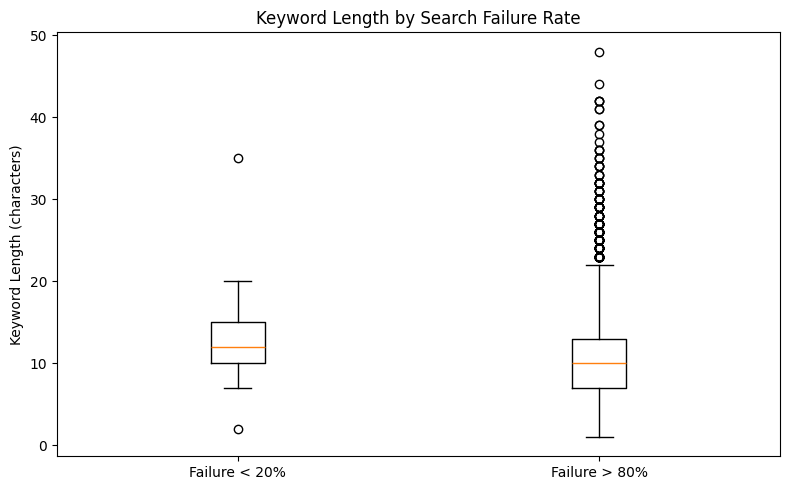

In [80]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

low_fail = keyword_perf[keyword_perf.failure_rate < 0.2]["keyword_length"]
high_fail = keyword_perf[keyword_perf.failure_rate > 0.8]["keyword_length"]

ax.boxplot([low_fail, high_fail], labels=["Failure < 20%", "Failure > 80%"])
ax.set_ylabel("Keyword Length (characters)")
ax.set_title("Keyword Length by Search Failure Rate")

print("Low failure (<0.2):", low_fail.describe().round(1).to_dict())
print("High failure (>0.8):", high_fail.describe().round(1).to_dict())

plt.tight_layout()
plt.show()

In [81]:
keyword_perf[(keyword_perf.failure_rate > 0.8) & (keyword_perf.keyword_length > 30)].sort_values("total_queries", ascending=False).head(10)[["keyword", "keyword_type", "total_queries", "failure_rate"]]


,keyword,keyword_type,total_queries,failure_rate
2578,Dolce & Gabbana D&G Slides in Rubber,latin,31,0.870968
1908,Charlotte tilbury flawless filter,latin,13,0.923077
16223,•\tCharlotte Tilbury Pillow Talk,latin,11,1.000000
12707,حقيبة كتف سوينجر 20 جاكار بشعار الماركة,arabic,7,0.857143
8240,The Ordinary Hyaluronic Acid 2% + B5,latin,7,0.857143
5121,Maria lucia hohan jolie midi dress,latin,7,0.857143
5632,NIKE Dunk Low Sneakers in Leather & Suede,latin,6,0.833333
350,Afternoon dress long sleeve dress,latin,6,1.000000
2806,Elisabetta franchi black shirt,latin,6,1.000000
3021,Fear of God Essentials in shorts,latin,5,1.000000


## Q3

<Axes: xlabel='index'>

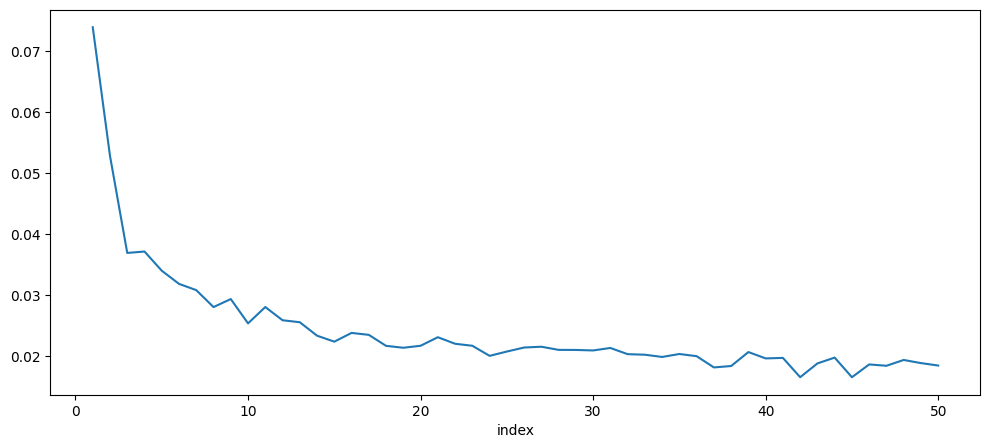

In [ ]:
#among products the user actually saw, what fraction did they click? 

position_ctr = search_df.groupby("index").agg(
    views=("plp_view", "sum"),
    clicks=("plp_click", "sum")
)
position_ctr["ctr"] = position_ctr["clicks"] / position_ctr["views"]
position_ctr["ctr"].iloc[:50].plot(figsize=(12, 5))

In [144]:
position_ctr.head(5)


,views,clicks,ctr
index,,,
1,81554,6024,0.073865
2,79774,4213,0.052812
3,76352,2820,0.036934
4,70127,2606,0.037161
5,52406,1783,0.034023


## Q4

In [ ]:
#Can you segment queries into different intent types? Do different query types behave differently?


In [ ]:
search_df.head(0) 

,dt,ts,user_id,app_country,keyword,index,product_id,productclass,class,designer,name,plp_view,plp_click,is_converted,index_reset,query_id,keyword_type,designer_lang_detected


In [ ]:
"""

Navigational / Brand-specific: User knows what they want. "Gucci," "Coach," "New Balance," "شانيل." The system's job is retrieval precision — find exactly that brand's products and rank by relevance within the brand.

Exploratory / Category-browsing: User is discovering. "Shoes," "Evening gowns," "Bag," "فساتين." The system's job is curation — surface the best products across brands, ranked by some combination of popularity, recency, and inferred preference.


"""

In [164]:
known_designers = set(search_df["designer"].dropna().str.lower().unique())
query_metrics["intent"] = query_metrics["keyword"].str.lower().apply(
    lambda x: "navigational" if x in known_designers else "exploratory"
)

In [188]:
query_metrics.groupby("intent").agg(
    queries=("num_clicks", "count"),
    success_rate=("num_clicks", lambda x: (x > 0).mean()),
    mrr=("reciprocal_rank", "mean"),
    conversion=("num_conversions", lambda x: (x > 0).mean())
)

,queries,success_rate,mrr,conversion
intent,,,,
exploratory,224789,0.290624,0.044695,0.014609
navigational,38813,0.272615,0.050541,0.024038


In [169]:
session_id_cols = ['user_id', 'keyword',"query_id"]

In [187]:
#query_metrics.groupby(session_id_cols).agg(total_clicks=("num_clicks","sum")).sort_values(by="total_clicks",ascending=False)[:30]

In [166]:
query_metrics.groupby("intent").agg(
    queries=("num_clicks", "count"),
    success_rate=("num_clicks", lambda x: (x > 0).mean()),
    mrr=("reciprocal_rank", "mean"),
    conversion=("num_conversions", lambda x: (x > 0).mean())
)

,queries,success_rate,mrr,conversion
intent,,,,
exploratory,224789,0.290624,0.044695,0.014609
navigational,38813,0.272615,0.050541,0.024038


# Understanding user ID distribution. Verifying assumption of power law distribution or right skewness

<Axes: >

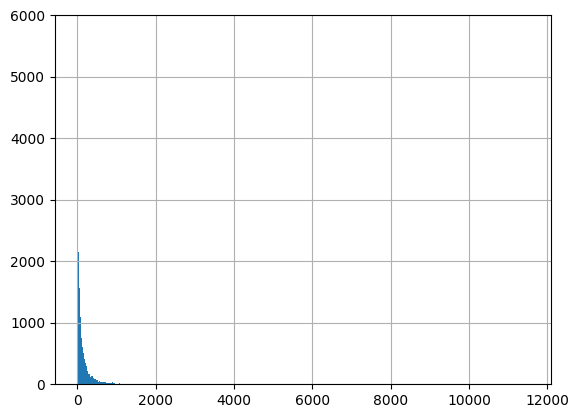

In [38]:
search_df.groupby(by=["user_id"]).size().sort_values(ascending=False).hist(bins=1000) # subset of users dominate search

In [36]:
str(round(search_df.keyword.nunique() / len(search_df.keyword),3) * 100) + '% of searches are unique'

'0.4% of searches are unique'